In [19]:
from pathlib import Path
import routing_map
from routing_map import build_aoi, RoutingMapConfig
from routing_map.config import AoiConfig, LandConfig

cfg = RoutingMapConfig(
    aoi=AoiConfig(
        bbox_ll=(100.0, 10, 135.0, 50),
    ),
    land=LandConfig(
        shp_path=Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp"),
        buffer_km=20.0,
        avoid_km= 1,
        collision_safety_km=0.5,
    ),
)

out = build_aoi(cfg)

[coverage] attach gates->C: s_km assigned 148/148
[coverage] spacing sample: before=148 after=130 removed=18 (spacing_km=120.0, min_per_ring=1)


In [20]:
print("bbox_ll:", out["bbox_ll"])
print("bbox_ll_sea:", out.get("bbox_ll_sea"))
print("Gate_all_cov:", len(out.get("Gate_all_cov", [])))
print("S_nodes:", len(out.get("S_nodes", [])), "S_edges:", len(out.get("S_edges", [])))
print("gateB_connectors:", len(out.get("gateB_connectors", [])))
print("Gate_B_kept_gates:", len(out.get("Gate_B_kept_gates", [])))
print("sc_bundle_stats:", out.get("sc_bundle_stats"))


bbox_ll: (100.0, 10, 135.0, 50)
bbox_ll_sea: (97.0, 7.0, 138.0, 53.0)
Gate_all_cov: 130
S_nodes: 291 S_edges: 390
gateB_connectors: 54
Gate_B_kept_gates: 24
sc_bundle_stats: {'edge_count': 390, 'node_count': 291, 'source': 'geograph_adjlist:latlon', 'cnt_latlon': 291, 'cnt_lonlat': 0}


In [46]:
print(out.get("gateB_connectors"))

    gate_uid  gate_row  g_id             source  sea_idx  \
0          0         0   248         A_COVERAGE      264   
1          0         0   248         A_COVERAGE      267   
2          0         0   248         A_COVERAGE      246   
3          4         4   242         A_COVERAGE      194   
4          5         5   241  A_COVERAGE_SNAP_F      162   
5          7         7   239         A_COVERAGE      118   
6          7         7   239         A_COVERAGE      148   
7          7         7   239         A_COVERAGE      135   
8          8         8   238         A_COVERAGE      116   
9          8         8   238         A_COVERAGE      104   
10         8         8   238         A_COVERAGE      109   
11         9         9   230         A_COVERAGE       82   
12         9         9   230         A_COVERAGE       96   
13        10        10   233  A_COVERAGE_SNAP_F       96   
14        10        10   233  A_COVERAGE_SNAP_F      100   
15        10        10   233  A_COVERAGE

In [8]:
print("S_edges len:", len(out["S_edges"]))
print("S_edges[0] type:", type(out["S_edges"][0]))
print("S_edges[0] =", out["S_edges"][0])



S_edges len: 192
S_edges[0] type: <class 'tuple'>
S_edges[0] = ((134.8599, 34.0982), (135.1, 34.3774))


### 檢查

In [12]:
import folium
import webbrowser
from pathlib import Path
import numpy as np
import pandas as pd

def open_routing_debug_map(
    out: dict,
    *,
    bbox_ll=None,
    html_path="aoi_debug_map.html",
    zoom_start=5,
    # sampling / limits
    c_sample=8000,
    s_sample=None,            # sea nodes sample; None=all
    max_sea_edges=6000,       # avoid too many lines
):
    # ---------------- bbox ----------------
    if bbox_ll is None:
        bbox_ll = out.get("bbox_ll", None)
    if bbox_ll is None:
        raise ValueError("bbox_ll is required (pass bbox_ll=... or ensure out['bbox_ll'] exists).")

    min_lon, min_lat, max_lon, max_lat = [float(x) for x in bbox_ll]
    center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]

    m = folium.Map(location=center, zoom_start=zoom_start, control_scale=True)

    # ---------------- color theme ----------------
    COLORS = {
        "bbox": "#A020F0",        # purple
        "C": "#1f77b4",           # blue
        "Gate_all": "#111111",    # near-black
        "Gate_A": "#d62728",      # red
        "Gate_F": "#ff7f0e",      # orange
        "Gate_B": "#6f42c1",      # violet
        "Sea": "#17becf",         # cyan (sea nodes + sea edges)
        "Conn": "#2ca02c",        # green (GateB->Sea connectors)
    }

    # bbox rectangle
    folium.Rectangle(
        bounds=[[min_lat, min_lon], [max_lat, max_lon]],
        fill=False, weight=3, opacity=0.9, color=COLORS["bbox"]
    ).add_to(m)
    m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

    # ---------------- helpers ----------------
    def _safe_df(name):
        df = out.get(name, None)
        if df is None:
            return None
        try:
            return df if len(df) > 0 else None
        except Exception:
            return None

    def _circle_layer(df, *, layer_name, radius, color, show=True, fill_opacity=0.75, line_opacity=0.9):
        fg = folium.FeatureGroup(name=layer_name, show=show)
        for _, r in df.iterrows():
            folium.CircleMarker(
                [float(r["lat"]), float(r["lon"])],
                radius=radius,
                color=color,
                weight=1,
                opacity=line_opacity,
                fill=True,
                fill_color=color,
                fill_opacity=fill_opacity,
            ).add_to(fg)
        fg.add_to(m)

    # gate lookup (g_id -> lon/lat)
    def _build_gate_xy():
        gate_df = _safe_df("Gate_all_cov")
        if gate_df is None:
            gate_df = _safe_df("Gate_all")
        if gate_df is None or ("g_id" not in gate_df.columns):
            return {}
        return {
            int(r["g_id"]): (float(r["lon"]), float(r["lat"]))
            for _, r in gate_df.iterrows()
        }

    gate_xy = _build_gate_xy()

    # sea node lookup by idx
    S_nodes = _safe_df("S_nodes")

    def _sea_lonlat_by_idx(i):
        s = S_nodes.iloc[int(i)]
        return float(s["lon"]), float(s["lat"])

    # sea edge to lonlat
    def _parse_node_id_str(s):
        try:
            a, b = s.split(",")
            return float(a), float(b)
        except Exception:
            return None

    def _edge_to_lonlat(e):
        """
        Return ((lon1,lat1),(lon2,lat2)) or None.
        Supports:
          1) (u_idx, v_idx) using S_nodes
          2) ((lon,lat),(lon,lat))
          3) ("lon,lat","lon,lat")
        """
        if not isinstance(e, (list, tuple)) or len(e) < 2:
            return None
        a, b = e[0], e[1]

        # (u_idx, v_idx)
        if isinstance(a, (int, np.integer)) and isinstance(b, (int, np.integer)):
            if S_nodes is None:
                return None
            try:
                p1 = _sea_lonlat_by_idx(a)
                p2 = _sea_lonlat_by_idx(b)
                return (p1, p2)
            except Exception:
                return None

        # ((lon,lat),(lon,lat))
        if isinstance(a, (list, tuple)) and isinstance(b, (list, tuple)) and len(a) >= 2 and len(b) >= 2:
            try:
                return ((float(a[0]), float(a[1])), (float(b[0]), float(b[1])))
            except Exception:
                return None

        # ("lon,lat","lon,lat")
        if isinstance(a, str) and isinstance(b, str):
            p1 = _parse_node_id_str(a)
            p2 = _parse_node_id_str(b)
            if p1 and p2:
                return (p1, p2)

        return None

    # ---------------- layers ----------------
    # C nodes
    dfC = _safe_df("C_nodes")
    if dfC is not None:
        nC = len(dfC)
        dfC_plot = dfC.sample(min(int(c_sample), nC), random_state=7) if nC > c_sample else dfC
        _circle_layer(
            dfC_plot,
            layer_name=f"C_nodes (sample {len(dfC_plot)}/{nC})",
            radius=1,
            color=COLORS["C"],
            show=True,
            fill_opacity=0.65,
            line_opacity=0.85,
        )

    # Gates: all / A / F
    # Gate_all_cov / Gate_all 用同一色（黑）
    for k, show, color in [
        ("Gate_all_cov", True, COLORS["Gate_all"]),
        ("Gate_all", True, COLORS["Gate_all"]),
        ("Gate_A", False, COLORS["Gate_A"]),
        ("Gate_F", False, COLORS["Gate_F"]),
    ]:
        dfG = _safe_df(k)
        if dfG is not None:
            _circle_layer(
                dfG,
                layer_name=f"{k} ({len(dfG)})",
                radius=4 if "Gate_all" in k else 5,
                color=color,
                show=show,
                fill_opacity=0.8,
                line_opacity=0.95,
            )

    # Gate B (kept gates)
    gb_obj = out.get("Gate_B_kept_gates", None)
    dfGB = None

    if gb_obj is not None:
        if isinstance(gb_obj, pd.DataFrame):
            dfGB = gb_obj.copy()
            if "lon" not in dfGB.columns or "lat" not in dfGB.columns:
                if "g_id" in dfGB.columns and gate_xy:
                    dfGB["lon"] = dfGB["g_id"].map(lambda x: gate_xy.get(int(x), (np.nan, np.nan))[0])
                    dfGB["lat"] = dfGB["g_id"].map(lambda x: gate_xy.get(int(x), (np.nan, np.nan))[1])
            dfGB = dfGB.dropna(subset=["lon", "lat"])
        elif isinstance(gb_obj, (list, set, tuple, np.ndarray)):
            gids = [int(x) for x in gb_obj]
            rows = []
            for gid in gids:
                if gid in gate_xy:
                    lon, lat = gate_xy[gid]
                    rows.append({"g_id": gid, "lon": lon, "lat": lat})
            dfGB = pd.DataFrame(rows)

    if dfGB is None:
        gb2 = _safe_df("Gate_B")
        if gb2 is not None:
            dfGB = gb2.copy()

    if dfGB is not None and len(dfGB) > 0:
        _circle_layer(
            dfGB,
            layer_name=f"Gate_B ({len(dfGB)})",
            radius=6,
            color=COLORS["Gate_B"],
            show=True,
            fill_opacity=0.85,
            line_opacity=0.95,
        )

    # Sea nodes
    if S_nodes is not None:
        nS = len(S_nodes)
        if s_sample is not None and nS > int(s_sample):
            dfS_plot = S_nodes.sample(int(s_sample), random_state=7)
            title = f"S_nodes (sample {len(dfS_plot)}/{nS})"
        else:
            dfS_plot = S_nodes
            title = f"S_nodes ({nS})"

        _circle_layer(
            dfS_plot,
            layer_name=title,
            radius=3,
            color=COLORS["Sea"],
            show=True,
            fill_opacity=0.75,
            line_opacity=0.9,
        )

    # Sea edges (same color as sea nodes)
    S_edges = out.get("S_edges", None)
    if S_nodes is not None and S_edges is not None and len(S_edges) > 0:
        fgE = folium.FeatureGroup(
            name=f"S_edges (show {min(len(S_edges), max_sea_edges)}/{len(S_edges)})",
            show=True
        )

        take = S_edges[:max_sea_edges] if len(S_edges) > max_sea_edges else S_edges
        drawn = 0
        for e in take:
            seg = _edge_to_lonlat(e)
            if seg is None:
                continue
            (lon1, lat1), (lon2, lat2) = seg
            folium.PolyLine(
                [[lat1, lon1], [lat2, lon2]],
                weight=2,
                opacity=0.7,
                color=COLORS["Sea"],
            ).add_to(fgE)
            drawn += 1

        fgE.add_to(m)
        print(f"[viz] sea edges drawn: {drawn}/{len(take)}")

    # GateB -> sea connectors (green)
    dfConn = _safe_df("gateB_connectors")
    if dfConn is not None and S_nodes is not None and gate_xy:
        fgConn = folium.FeatureGroup(name=f"GateB→Sea connectors ({len(dfConn)})", show=True)

        kept_gids = None
        if dfGB is not None and "g_id" in dfGB.columns and len(dfGB) > 0:
            kept_gids = set(int(x) for x in dfGB["g_id"].values)

        drawn = 0
        for _, r in dfConn.iterrows():
            gid = int(r["g_id"])
            if kept_gids is not None and gid not in kept_gids:
                continue
            if gid not in gate_xy:
                continue
            lon_g, lat_g = gate_xy[gid]
            try:
                lon_s, lat_s = _sea_lonlat_by_idx(int(r["sea_idx"]))
            except Exception:
                continue

            folium.PolyLine(
                [[lat_g, lon_g], [lat_s, lon_s]],
                weight=2,
                opacity=0.95,
                color=COLORS["Conn"],
            ).add_to(fgConn)
            drawn += 1

        fgConn.add_to(m)
        print(f"[viz] GateB→Sea connectors drawn: {drawn}/{len(dfConn)}")

    folium.LayerControl(collapsed=False).add_to(m)

    html_path = Path(html_path).resolve()
    m.save(str(html_path))
    webbrowser.open(html_path.as_uri())
    return html_path


In [21]:
html = open_routing_debug_map(out, bbox_ll=out["bbox_ll"], html_path="aoi_debug_map.html")
print("saved:", html)


[viz] sea edges drawn: 390/390
[viz] GateB→Sea connectors drawn: 54/54
saved: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\aoi_debug_map.html


### Phase I 驗收

In [8]:
import folium
import webbrowser
from pathlib import Path
import numpy as np
import pandas as pd

def open_routing_debug_map(
    out: dict,
    *,
    bbox_ll=None,
    html_path="aoi_debug_map.html",
    zoom_start=5,
    # sampling / limits
    c_sample=8000,
    s_sample=None,            # sea nodes sample; None=all
    max_sea_edges=6000,       # avoid too many lines
):
    # ---------------- bbox ----------------
    if bbox_ll is None:
        bbox_ll = out.get("bbox_ll", None)
    if bbox_ll is None:
        raise ValueError("bbox_ll is required (pass bbox_ll=... or ensure out['bbox_ll'] exists).")

    min_lon, min_lat, max_lon, max_lat = [float(x) for x in bbox_ll]
    center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]

    m = folium.Map(location=center, zoom_start=zoom_start, control_scale=True)

    # bbox rectangle
    folium.Rectangle(
        bounds=[[min_lat, min_lon], [max_lat, max_lon]],
        fill=False, weight=3, opacity=0.9
    ).add_to(m)
    m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

    # ---------------- helpers ----------------
    def _safe_df(name):
        df = out.get(name, None)
        if df is None:
            return None
        try:
            return df if len(df) > 0 else None
        except Exception:
            return None

    def _circle_layer(df, *, layer_name, radius, show=True):
        fg = folium.FeatureGroup(name=layer_name, show=show)
        for _, r in df.iterrows():
            folium.CircleMarker([float(r["lat"]), float(r["lon"])], radius=radius).add_to(fg)
        fg.add_to(m)

    # gate lookup (g_id -> lon/lat)
    def _build_gate_xy():
        # coverage 後優先：不要用 `or`，DataFrame 不能做 truthy 判斷
        gate_df = _safe_df("Gate_all_cov")
        if gate_df is None:
            gate_df = _safe_df("Gate_all")

        if gate_df is None or ("g_id" not in gate_df.columns):
            return {}

        return {
            int(r["g_id"]): (float(r["lon"]), float(r["lat"]))
            for _, r in gate_df.iterrows()
        }

    gate_xy = _build_gate_xy()

    # sea node lookup by idx
    S_nodes = _safe_df("S_nodes")

    def _sea_lonlat_by_idx(i):
        s = S_nodes.iloc[int(i)]
        return float(s["lon"]), float(s["lat"])

    # sea edge to lonlat
    def _parse_node_id_str(s):
        try:
            a, b = s.split(",")
            return float(a), float(b)
        except Exception:
            return None

    def _edge_to_lonlat(e):
        """
        Return ((lon1,lat1),(lon2,lat2)) or None.
        Supports:
          1) (u_idx, v_idx) using S_nodes
          2) ((lon,lat),(lon,lat))
          3) ("lon,lat","lon,lat")
        """
        if not isinstance(e, (list, tuple)) or len(e) < 2:
            return None
        a, b = e[0], e[1]

        # (u_idx, v_idx)
        if isinstance(a, (int, np.integer)) and isinstance(b, (int, np.integer)):
            if S_nodes is None:
                return None
            try:
                p1 = _sea_lonlat_by_idx(a)
                p2 = _sea_lonlat_by_idx(b)
                return (p1, p2)
            except Exception:
                return None

        # ((lon,lat),(lon,lat))
        if isinstance(a, (list, tuple)) and isinstance(b, (list, tuple)) and len(a) >= 2 and len(b) >= 2:
            try:
                return ((float(a[0]), float(a[1])), (float(b[0]), float(b[1])))
            except Exception:
                return None

        # ("lon,lat","lon,lat")
        if isinstance(a, str) and isinstance(b, str):
            p1 = _parse_node_id_str(a)
            p2 = _parse_node_id_str(b)
            if p1 and p2:
                return (p1, p2)

        return None

    # ---------------- layers ----------------
    # C nodes
    dfC = _safe_df("C_nodes")
    if dfC is not None:
        nC = len(dfC)
        dfC_plot = dfC.sample(min(int(c_sample), nC), random_state=7) if nC > c_sample else dfC
        _circle_layer(dfC_plot, layer_name=f"C_nodes (sample {len(dfC_plot)}/{nC})", radius=1, show=True)

    # Gates: all / A / F
    for k, show in [("Gate_all_cov", True), ("Gate_all", True), ("Gate_A", False), ("Gate_F", False)]:
        dfG = _safe_df(k)
        if dfG is not None:
            _circle_layer(dfG, layer_name=f"{k} ({len(dfG)})", radius=4, show=show)

    # Gate B (kept gates)
    gb_obj = out.get("Gate_B_kept_gates", None)
    dfGB = None

    if gb_obj is not None:
        if isinstance(gb_obj, pd.DataFrame):
            dfGB = gb_obj.copy()
            if "lon" not in dfGB.columns or "lat" not in dfGB.columns:
                if "g_id" in dfGB.columns and gate_xy:
                    dfGB["lon"] = dfGB["g_id"].map(lambda x: gate_xy.get(int(x), (np.nan, np.nan))[0])
                    dfGB["lat"] = dfGB["g_id"].map(lambda x: gate_xy.get(int(x), (np.nan, np.nan))[1])
            dfGB = dfGB.dropna(subset=["lon", "lat"])
        elif isinstance(gb_obj, (list, set, tuple, np.ndarray)):
            gids = [int(x) for x in gb_obj]
            rows = []
            for gid in gids:
                if gid in gate_xy:
                    lon, lat = gate_xy[gid]
                    rows.append({"g_id": gid, "lon": lon, "lat": lat})
            dfGB = pd.DataFrame(rows)

    # fallback: maybe out["Gate_B"] exists
    if dfGB is None:
        gb2 = _safe_df("Gate_B")
        if gb2 is not None:
            dfGB = gb2.copy()

    if dfGB is not None and len(dfGB) > 0:
        _circle_layer(dfGB, layer_name=f"Gate_B ({len(dfGB)})", radius=6, show=True)

    # Sea nodes
    if S_nodes is not None:
        nS = len(S_nodes)
        if s_sample is not None and nS > int(s_sample):
            dfS_plot = S_nodes.sample(int(s_sample), random_state=7)
            title = f"S_nodes (sample {len(dfS_plot)}/{nS})"
        else:
            dfS_plot = S_nodes
            title = f"S_nodes ({nS})"
        _circle_layer(dfS_plot, layer_name=title, radius=3, show=True)

    # Sea edges
    S_edges = out.get("S_edges", None)
    if S_nodes is not None and S_edges is not None and len(S_edges) > 0:
        fgE = folium.FeatureGroup(name=f"S_edges (show {min(len(S_edges), max_sea_edges)}/{len(S_edges)})", show=True)

        take = S_edges[:max_sea_edges] if len(S_edges) > max_sea_edges else S_edges
        drawn = 0
        for e in take:
            seg = _edge_to_lonlat(e)
            if seg is None:
                continue
            (lon1, lat1), (lon2, lat2) = seg
            folium.PolyLine([[lat1, lon1], [lat2, lon2]], weight=2, opacity=0.8).add_to(fgE)
            drawn += 1

        fgE.add_to(m)
        print(f"[viz] sea edges drawn: {drawn}/{len(take)}")

    # GateB -> sea connectors
    dfConn = _safe_df("gateB_connectors")
    if dfConn is not None and S_nodes is not None and gate_xy:
        fgConn = folium.FeatureGroup(name=f"GateB→Sea connectors ({len(dfConn)})", show=True)

        kept_gids = None
        if dfGB is not None and "g_id" in dfGB.columns and len(dfGB) > 0:
            kept_gids = set(int(x) for x in dfGB["g_id"].values)

        drawn = 0
        for _, r in dfConn.iterrows():
            gid = int(r["g_id"])
            if kept_gids is not None and gid not in kept_gids:
                continue
            if gid not in gate_xy:
                continue
            lon_g, lat_g = gate_xy[gid]
            try:
                lon_s, lat_s = _sea_lonlat_by_idx(int(r["sea_idx"]))
            except Exception:
                continue

            folium.PolyLine([[lat_g, lon_g], [lat_s, lon_s]], weight=2, opacity=0.95).add_to(fgConn)
            drawn += 1

        fgConn.add_to(m)
        print(f"[viz] GateB→Sea connectors drawn: {drawn}/{len(dfConn)}")

    folium.LayerControl(collapsed=False).add_to(m)

    html_path = Path(html_path).resolve()
    m.save(str(html_path))
    webbrowser.open(html_path.as_uri())
    return html_path


#### 畫圖

In [9]:
html = open_routing_debug_map(out, bbox_ll=out["bbox_ll"], html_path="aoi_debug_map.html")
print("saved:", html)


[viz] sea edges drawn: 390/390
[viz] GateB→Sea connectors drawn: 9/9
saved: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\aoi_debug_map.html


In [48]:
import networkx as nx
import numpy as np
import pandas as pd

def test_gate_navigation_v8_final_fixed(out):
    G = nx.Graph()
    
    # 1. 解析海洋路網 (S_edges) - 節點是 tuple
    sea_edges = out.get('S_edges', [])
    for u, v in sea_edges:
        dist = np.sqrt((u[0]-v[0])**2 + (u[1]-v[1])**2)
        G.add_edge(u, v, weight=dist, type='sea')

    # 2. 解析 Gate_B 座標 (建立 g_id 到 座標的對照)
    gates_df = out.get('Gate_B_kept_gates')
    gate_id_to_ll = {}
    if isinstance(gates_df, pd.DataFrame):
        for _, row in gates_df.iterrows():
            # 根據你提供的欄位，g_id 是關聯鍵
            ll = (row['lon'], row['lat'])
            gate_id_to_ll[row['g_id']] = ll

    # 3. 解析 gateB_connectors (執行「焊接」)
    conn_df = out.get('gateB_connectors')
    if isinstance(conn_df, pd.DataFrame):
        for _, row in conn_df.iterrows():
            # A. 取得 Gate 座標
            g_ll = gate_id_to_ll.get(row['g_id'])
            
            # B. 取得 Sea Node 座標
            # 處理字串格式 "135.456200,42.237800"
            s_raw = row['sea_node_id']
            try:
                if isinstance(s_raw, str):
                    s_ll = tuple(map(float, s_raw.split(',')))
                else:
                    s_ll = s_raw
                
                if g_ll and s_ll:
                    # 計算距離並連線
                    dist = np.sqrt((g_ll[0]-s_ll[0])**2 + (g_ll[1]-s_ll[1])**2)
                    G.add_edge(g_ll, s_ll, weight=dist, type='connector')
                    G.nodes[g_ll]['type'] = 'gate'
            except:
                continue

    # 4. 統計與測試
    valid_gates = [ll for ll in gate_id_to_ll.values() if ll in G]
    print(f" 最終結果：節點={G.number_of_nodes()}, 邊={G.number_of_edges()}")
    print(f" 成功焊接進圖中的 Gate 數量: {len(valid_gates)}")

    if len(valid_gates) < 2:
        print(" 焊接失敗，請確認 Gate 與 Sea Node 的座標格式是否完全一致。")
        return None

    # 5. A* 導航
    try:
        start_node, end_node = valid_gates[0], valid_gates[-1]
        path = nx.astar_path(G, start_node, end_node, 
                             heuristic=lambda n1, n2: np.sqrt((n1[0]-n2[0])**2 + (n1[1]-n2[1])**2), 
                             weight='weight')
        
        edges_in_path = list(zip(path, path[1:]))
        conn_used = sum(1 for u, v in edges_in_path if G[u][v].get('type') == 'connector')
        
        print(f" 導航成功！路徑點數: {len(path)}, 跨越 Connector 次數: {conn_used}")
        return path
    except Exception as e:
        print(f" 導航失敗: {e}")
        return None

path = test_gate_navigation_v8_final_fixed(out)

 最終結果：節點=314, 邊=444
 成功焊接進圖中的 Gate 數量: 24
 導航成功！路徑點數: 23, 跨越 Connector 次數: 2


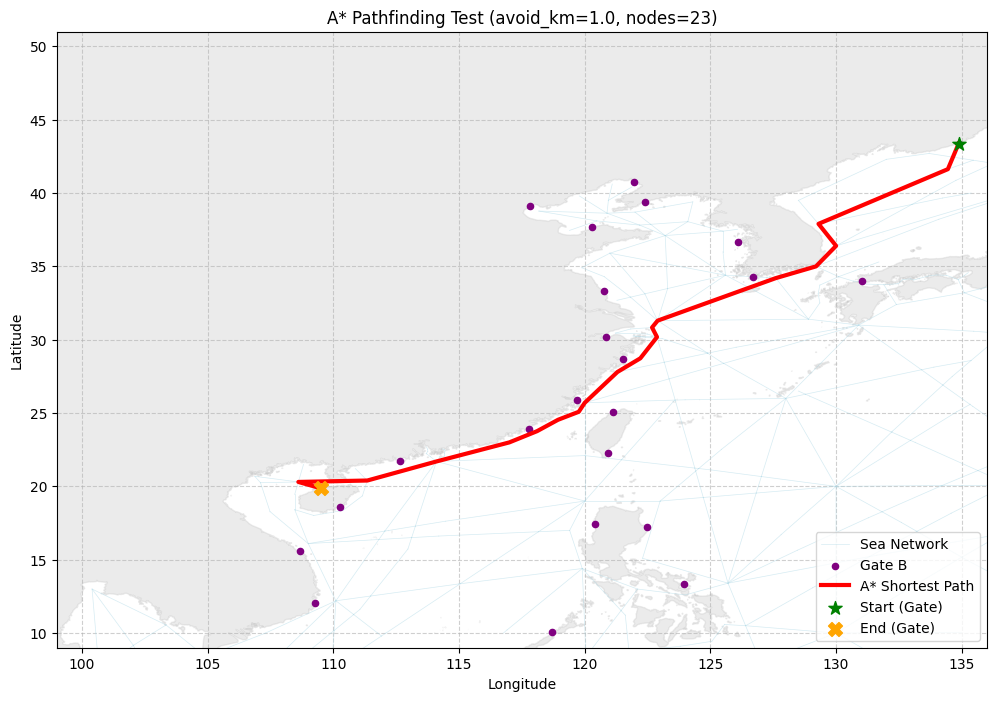

In [49]:
import matplotlib.pyplot as plt

def plot_routing_path(out, path):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 1. 畫出所有海洋路網 (Sea Edges) - 淺灰色作為底色
    sea_edges = out.get('S_edges', [])
    for i, (u, v) in enumerate(sea_edges):
        label = 'Sea Network' if i == 0 else ""
        ax.plot([u[0], v[0]], [u[1], v[1]], color='lightblue', linewidth=0.5, alpha=0.5, label=label)
        
    # 2. 畫出 Gate_B_kept_gates - 紫色點
    gates_df = out.get('Gate_B_kept_gates')
    ax.scatter(gates_df['lon'], gates_df['lat'], color='purple', s=20, label='Gate B', zorder=5)
    
    # 3. 畫出 A* 導航路徑 - 粗紅線
    if path:
        path_lon = [p[0] for p in path]
        path_lat = [p[1] for p in path]
        ax.plot(path_lon, path_lat, color='red', linewidth=3, label='A* Shortest Path', zorder=10)
        
        # 標註起點與終點
        ax.scatter(path_lon[0], path_lat[0], color='green', s=100, marker='*', label='Start (Gate)', zorder=12)
        ax.scatter(path_lon[-1], path_lat[-1], color='orange', s=100, marker='X', label='End (Gate)', zorder=12)

    # 4. 畫出陸地輪廓 (如果 out 裡面有 polys_ll)
    polys = out.get('polys_ll', [])
    for poly in polys:
        if hasattr(poly, 'exterior'):
            x, y = poly.exterior.xy
            ax.fill(x, y, color='silver', alpha=0.3, zorder=1)

    ax.set_title(f"A* Pathfinding Test (avoid_km=1.0, nodes={len(path)})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # 設定顯示範圍為 bbox
    bbox = out.get('bbox_ll')
    if bbox:
        ax.set_xlim(bbox[0]-1, bbox[2]+1)
        ax.set_ylim(bbox[1]-1, bbox[3]+1)
        
    plt.show()

# 執行繪圖
plot_routing_path(out, path)

In [50]:
import folium
from folium import plugins
import webbrowser
import os

def plot_path_folium_and_open(out, path, filename="nav_test_map.html"):
    # 1. 計算地圖中心點 (Bbox 中點)
    bbox = out.get('bbox_ll', (0, 0, 0, 0))
    center_lat = (bbox[1] + bbox[3]) / 2
    center_lon = (bbox[0] + bbox[2]) / 2
    
    # 建立地圖底圖
    m = folium.Map(
        location=[center_lat, center_lon], 
        zoom_start=6, 
        tiles='https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png',
        attr='&copy; OpenStreetMap contributors, Tiles style by Humanitarian OpenStreetMap Team'
    )

    # 2. 繪製海洋路網 (Sea Network)
    sea_layer = folium.FeatureGroup(name='Sea Edges (Ocean Path)')
    sea_edges = out.get('S_edges', [])
    for u, v in sea_edges:
        folium.PolyLine(
            locations=[[u[1], u[0]], [v[1], v[0]]], 
            color='#3388ff', weight=1, opacity=0.4
        ).add_to(sea_layer)
    sea_layer.add_to(m)

    # 3. 繪製 Gate B (Purple Points)
    gate_layer = folium.FeatureGroup(name='Gate B (Entry/Exit)')
    gates_df = out.get('Gate_B_kept_gates')
    for _, row in gates_df.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=4, color='purple', fill=True, fill_opacity=0.7,
            popup=f"Gate UID: {row.get('gate_uid', 'N/A')}<br>LL: {row['lat']:.4f}, {row['lon']:.4f}"
        ).add_to(gate_layer)
    gate_layer.add_to(m)

    # 4. 繪製 A* 導航結果路徑
    if path:
        # 將路徑轉換為 Folium 格式 [[lat, lon], ...]
        path_latlon = [[p[1], p[0]] for p in path]
        
        # 繪製紅線路徑
        folium.PolyLine(
            locations=path_latlon, 
            color='red', weight=5, opacity=0.9, 
            name='A* Path'
        ).add_to(m)
        
        # 標記起點 (Start)
        folium.Marker(
            location=path_latlon[0], 
            popup='Departure Gate', 
            icon=folium.Icon(color='green', icon='ship', prefix='fa')
        ).add_to(m)
        
        # 標記終點 (End)
        folium.Marker(
            location=path_latlon[-1], 
            popup='Destination Gate', 
            icon=folium.Icon(color='orange', icon='anchor', prefix='fa')
        ).add_to(m)

    # 5. 地圖功能增強
    folium.LayerControl().add_to(m)
    plugins.Fullscreen().add_to(m)
    plugins.MeasureControl(position='topleft', primary_length_unit='nauticalmiles').add_to(m) # 加入航里測量工具

    # 6. 存檔並自動開啟瀏覽器
    m.save(filename)
    full_path = "file://" + os.path.realpath(filename)
    print(f"地圖已生成：{full_path}")
    webbrowser.open(full_path)

# 執行繪圖並開啟瀏覽器
plot_path_folium_and_open(out, path)

地圖已生成：file://C:\Users\slab\Desktop\Slab Project\Stage2 ETA\nav_test_map.html
